In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
print("\nLoading Dataset...\n")


Loading Dataset...



In [29]:
df = pd.read_csv("/content/student_performance_data [1].csv")

In [24]:
print("========== FIRST 5 ROWS ==========")
print(df.head())


========== FIRST 5 ROWS ==========
   student_id  gender  study_hours_per_day  attendance_percentage  \
0      100000    Male                 4.54                  69.98   
1      100001  Female                 5.26                  84.80   
2      100002    Male                 8.69                  73.76   
3      100003    Male                 4.06                  45.00   
4      100004    Male                 8.83                  51.13   

   assignment_score  midterm_score  final_exam_score  participation_score  \
0             36.47          70.70             53.10                17.96   
1             34.25          27.92             87.17                11.29   
2             72.29          70.92             99.61                76.10   
3             97.63          31.73             88.85                33.55   
4             65.19          78.28             54.23                88.99   

  internet_access extra_classes parent_education  sleep_hours  overall_score  \
0      

In [25]:
print("\n========== DATASET INFO ==========")
print(df.info())

# ---------------------------------
# CHECK NULL VALUES
# ---------------------------------

print("\n========== NULL VALUES ==========")
print(df.isnull().sum())

# ---------------------------------
# BASIC STATISTICS
# ---------------------------------

print("\n========== DATASET STATISTICS ==========")
print(df.describe())




========== DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  int64  
 1   gender                 10000 non-null  object 
 2   study_hours_per_day    10000 non-null  float64
 3   attendance_percentage  10000 non-null  float64
 4   assignment_score       10000 non-null  float64
 5   midterm_score          10000 non-null  float64
 6   final_exam_score       10000 non-null  float64
 7   participation_score    10000 non-null  float64
 8   internet_access        10000 non-null  object 
 9   extra_classes          10000 non-null  object 
 10  parent_education       10000 non-null  object 
 11  sleep_hours            10000 non-null  float64
 12  overall_score          10000 non-null  float64
 13  grade                  10000 non-null  object 
dtypes: float64(8), int6

In [26]:
average_score = df["overall_score"].mean()

print("\n========== AVERAGE SCORE ==========")
print("Average Overall Score:", round(average_score, 2))

# ---------------------------------
# HIGHEST SCORING STUDENT
# ---------------------------------

highest_student = df.loc[df["overall_score"].idxmax()]

print("\n========== TOPPER DETAILS ==========")
print(highest_student)

# ---------------------------------
# LOWEST SCORING STUDENT
# ---------------------------------

lowest_student = df.loc[df["overall_score"].idxmin()]

print("\n========== LOWEST SCORER ==========")
print(lowest_student)



========== AVERAGE SCORE ==========
Average Overall Score: 63.83

========== TOPPER DETAILS ==========
student_id                 105745
gender                       Male
study_hours_per_day          6.22
attendance_percentage       98.96
assignment_score            96.15
midterm_score               99.64
final_exam_score            97.79
participation_score         86.17
internet_access               Yes
extra_classes                 Yes
parent_education         Bachelor
sleep_hours                  4.64
overall_score             96.8795
grade                           A
Name: 5745, dtype: object

========== LOWEST SCORER ==========
student_id                 103179
gender                       Male
study_hours_per_day          1.85
attendance_percentage        59.8
assignment_score            30.78
midterm_score               27.32
final_exam_score            34.53
participation_score         22.12
internet_access                No
extra_classes                  No
parent_education 

In [27]:
print("\n========== GRADE DISTRIBUTION ==========")
print(df["grade"].value_counts())

# ---------------------------------
# GENDER-WISE PERFORMANCE
# ---------------------------------

gender_performance = df.groupby("gender")["overall_score"].mean()

print("\n========== GENDER PERFORMANCE ==========")
print(gender_performance)

# ---------------------------------
# ATTENDANCE ANALYSIS
# ---------------------------------

attendance_average = df["attendance_percentage"].mean()

print("\n========== ATTENDANCE ANALYSIS ==========")
print("Average Attendance:", round(attendance_average, 2))

# ---------------------------------
# STUDY HOURS ANALYSIS
# ---------------------------------

study_hours_average = df["study_hours_per_day"].mean()

print("\n========== STUDY HOURS ANALYSIS ==========")
print("Average Study Hours:", round(study_hours_average, 2))



========== GRADE DISTRIBUTION ==========
grade
C    5073
B    2704
D    2008
A     154
F      61
Name: count, dtype: int64

========== GENDER PERFORMANCE ==========
gender
Female    63.830053
Male      63.823766
Name: overall_score, dtype: float64

========== ATTENDANCE ANALYSIS ==========
Average Attendance: 70.49

========== STUDY HOURS ANALYSIS ==========
Average Study Hours: 5.47


In [28]:
print("\n========== TOP 10 STUDENTS ==========")


========== TOP 10 STUDENTS ==========


In [30]:
top_students = df.sort_values(
    by="overall_score",
    ascending=False
).head(10)

print(top_students[["student_id", "overall_score", "grade"]])


      student_id  overall_score grade
5745      105745        96.8795     A
8453      108453        95.2065     A
7374      107374        94.0470     A
3598      103598        93.4150     A
4667      104667        92.7165     A
12        100012        92.3830     A
7472      107472        91.9345     A
7667      107667        91.8645     A
8563      108563        91.7020     A
2135      102135        91.6830     A


In [31]:
top_students.to_csv(
    "top_students_report.csv",
    index=False
)

print("\nTop students report saved successfully.")



Top students report saved successfully.


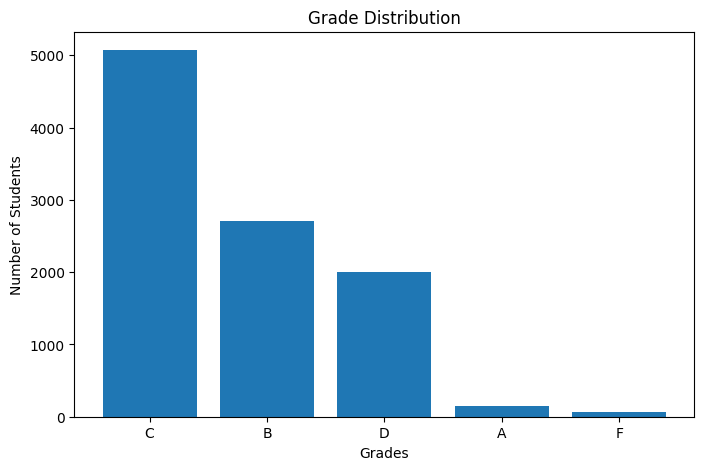

In [32]:
grade_counts = df["grade"].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(
    grade_counts.index,
    grade_counts.values
)

plt.title("Grade Distribution")
plt.xlabel("Grades")
plt.ylabel("Number of Students")

plt.show()


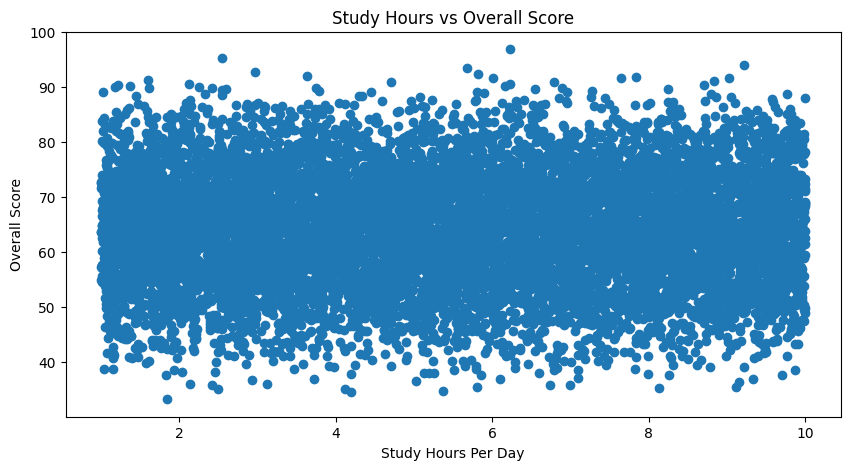

In [41]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["study_hours_per_day"],
    df["overall_score"]
)

plt.title("Study Hours vs Overall Score")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Overall Score")

plt.show()



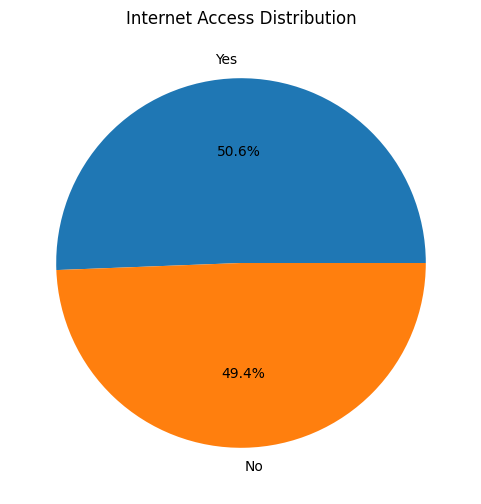

In [34]:
internet_counts = df["internet_access"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    internet_counts.values,
    labels=internet_counts.index,
    autopct="%1.1f%%"
)

plt.title("Internet Access Distribution")

plt.show()


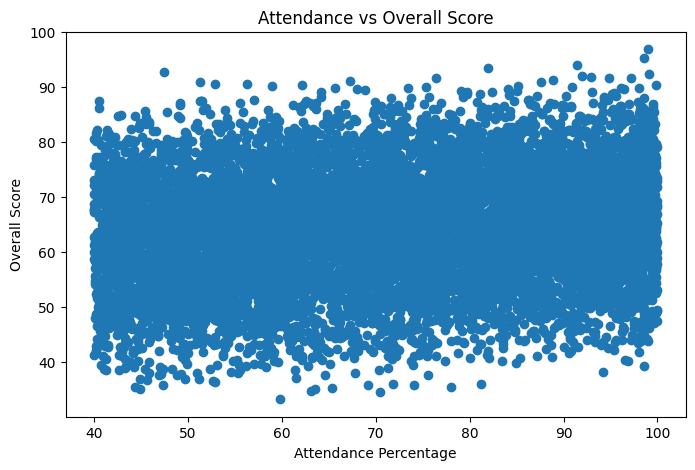

In [35]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["attendance_percentage"],
    df["overall_score"]
)

plt.title("Attendance vs Overall Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Overall Score")

plt.show()



<Axes: >

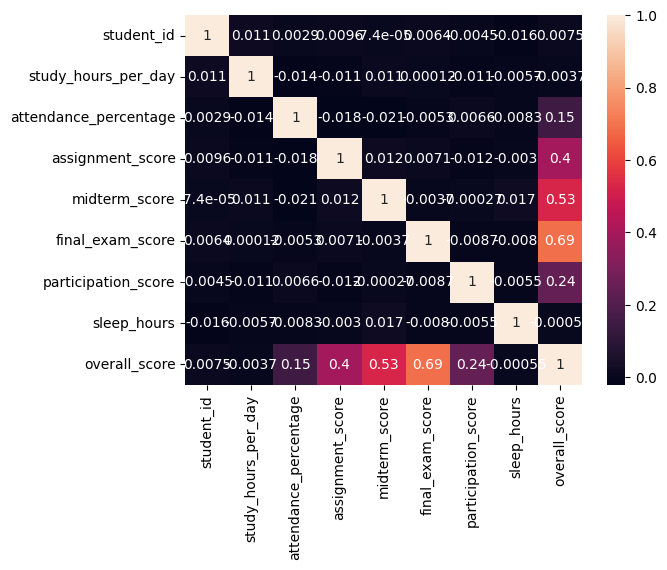

In [42]:
import seaborn as sns

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

In [36]:
sleep_average = df["sleep_hours"].mean()

print("\n========== SLEEP ANALYSIS ==========")
print("Average Sleep Hours:", round(sleep_average, 2))



========== SLEEP ANALYSIS ==========
Average Sleep Hours: 6.51


In [37]:
correlation = df[[
    "study_hours_per_day",
    "attendance_percentage",
    "sleep_hours",
    "overall_score"
]].corr()

print("\n========== CORRELATION MATRIX ==========")
print(correlation)



========== CORRELATION MATRIX ==========
                       study_hours_per_day  attendance_percentage  \
study_hours_per_day               1.000000              -0.014053   
attendance_percentage            -0.014053               1.000000   
sleep_hours                      -0.005728              -0.008273   
overall_score                    -0.003651               0.148781   

                       sleep_hours  overall_score  
study_hours_per_day      -0.005728      -0.003651  
attendance_percentage    -0.008273       0.148781  
sleep_hours               1.000000      -0.000551  
overall_score            -0.000551       1.000000  


In [38]:
df.to_csv(
    "final_student_analysis_report.csv",
    index=False
)

print("\nFinal analysis report saved successfully.")



Final analysis report saved successfully.


In [39]:
print("\n========== PROJECT COMPLETED ==========")


========== PROJECT COMPLETED ==========
